# Baseline Mortgage Delinquency Modeling


Develop and compare baseline models on the 2019 sample before moving to multi-vintage out-of-time validation.


This notebook is a development sandbox using a random 2019 train/test split and the corrected calendar-based target from `01_data_ingestion.ipynb`. Final model selection and reported out-of-time performance are handled in `05_macroeconomic_data.ipynb`.


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingClassifier)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

## 2. Load Modeling Data

In [2]:
model_data = pd.read_parquet("../data/processed/model_data_2019.parquet")

model_data.shape

(49897, 31)

## 3. Feature Selection

In [3]:
features = [
    "credit_score",
    "dti",
    "cltv",
    "original_interest_rate"
]

target = "seriously_delinquent_24m"

X = model_data[features]
y = model_data[target]

In [4]:
X.head()

,credit_score,dti,cltv,original_interest_rate
0,741.0,33.0,80.0,5.125
1,731.0,44.0,77.0,4.875
2,722.0,41.0,95.0,5.500
3,729.0,17.0,87.0,5.090
4,773.0,43.0,29.0,5.375


In [5]:
y.value_counts(normalize=True)

seriously_delinquent_24m
False    0.954206
True     0.045794
Name: proportion, dtype: float64

## 4. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining target rate:")
print(y_train.mean())

print("\nTest target rate:")
print(y_test.mean())

Training rows: 39917
Test rows: 9980

Training target rate:
0.045795024676203125

Test target rate:
0.04579158316633267


## 5. Preprocessing

### 5.1 Missing Values

In [8]:
X_train.isna().sum()

credit_score              13
dti                       25
cltv                       1
original_interest_rate     0
dtype: int64

In [9]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [10]:
pd.DataFrame({
    "feature": features,
    "training_median": imputer.statistics_
})

,feature,training_median
0,credit_score,757.000
1,dti,37.000
2,cltv,80.000
3,original_interest_rate,4.125


In [11]:
print("Missing training values:", pd.isna(X_train_imputed).sum())
print("Missing test values:", pd.isna(X_test_imputed).sum())

Missing training values: 0
Missing test values: 0


### 5.2 Feature Scaling

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [13]:
print("Training means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining standard deviations:")
print(X_train_scaled.std(axis=0))

Training means:
[-6.32807933e-16  1.99365650e-17 -1.84413226e-16  3.99087310e-16]

Training standard deviations:
[1. 1. 1. 1.]


## 6. Logistic Regression Baseline

### 6.1 Train Model

In [14]:
log_reg = LogisticRegression(random_state=42)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

### 6.2 Generate Predictions

In [15]:
y_pred = log_reg.predict(X_test_scaled)

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

In [16]:
pd.Series(y_prob).describe()

count    9980.000000
mean        0.045437
std         0.034120
min         0.001721
25%         0.020652
50%         0.036323
75%         0.060184
max         0.256228
dtype: float64

In [17]:
pd.Series(y_pred).value_counts()

False    9980
Name: count, dtype: int64

## 7. Model Evaluation

### 7.1 Default Classification Performance

In [18]:
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, zero_division=0))

[[9523    0]
 [ 457    0]]

              precision    recall  f1-score   support

       False       0.95      1.00      0.98      9523
        True       0.00      0.00      0.00       457

    accuracy                           0.95      9980
   macro avg       0.48      0.50      0.49      9980
weighted avg       0.91      0.95      0.93      9980



### 7.2 Evaluating Risk Ranking

In [19]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

ROC-AUC: 0.712
PR-AUC: 0.113


### 7.3 Classification Threshold

In [20]:
y_pred_10 = y_prob >= 0.10

print("Loans flagged:", y_pred_10.sum())
print(f"Precision: {precision_score(y_test, y_pred_10):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_10):.3f}")
print()
print(confusion_matrix(y_test, y_pred_10))

Loans flagged: 782
Precision: 0.136
Recall: 0.232

[[8847  676]
 [ 351  106]]


### 7.4 Threshold Comparison

In [21]:
thresholds = [0.05, 0.075, 0.10, 0.15, 0.20]

results = []

for threshold in thresholds:
    predictions = y_prob >= threshold

    results.append({
        "threshold": threshold,
        "loans_flagged": predictions.sum(),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,loans_flagged,precision,recall
0,0.050,3374,0.085359,0.630197
1,0.075,1636,0.106968,0.382932
2,0.100,782,0.135550,0.231947
3,0.150,161,0.192547,0.067834
4,0.200,23,0.260870,0.013129


### 7.5 ROC and Precision-Recall Curves

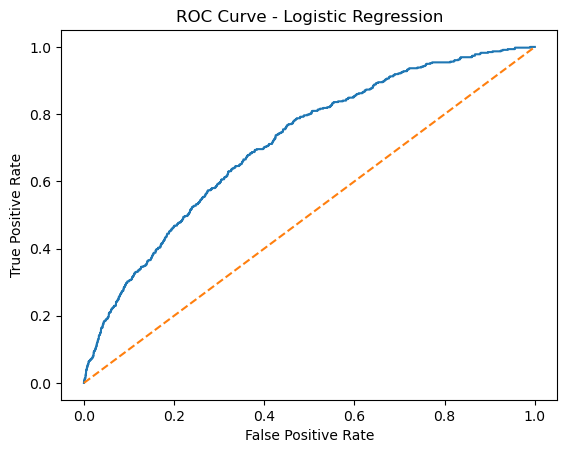

In [22]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

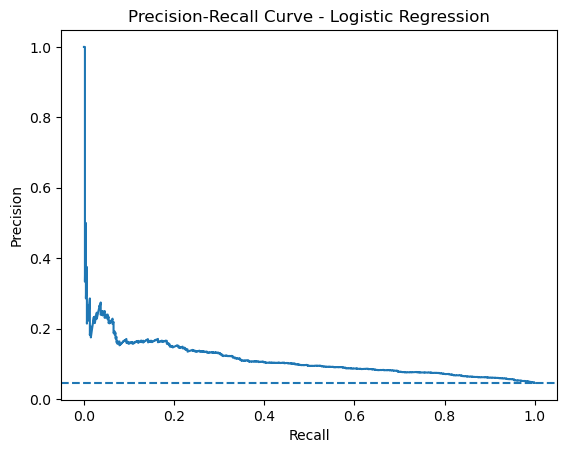

In [23]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.plot(recall, precision)
plt.axhline(
    y=y_test.mean(),
    linestyle="--"
)

plt.title("Precision-Recall Curve - Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## 8. Model Interpretation

### 8.1 Logistic Regression Coefficients

In [24]:
coefficient_df = pd.DataFrame({
    "feature": features,
    "coefficient": log_reg.coef_[0]
})

coefficient_df = coefficient_df.sort_values(
    "coefficient",
    ascending=False
)

coefficient_df

,feature,coefficient
1,dti,0.395501
2,cltv,0.311951
3,original_interest_rate,0.055435
0,credit_score,-0.526821


### 8.2 Odds Ratios

In [25]:
coefficient_df["odds_ratio"] = np.exp(

    coefficient_df["coefficient"]

)

coefficient_df

,feature,coefficient,odds_ratio
1,dti,0.395501,1.485128
2,cltv,0.311951,1.366088
3,original_interest_rate,0.055435,1.057000
0,credit_score,-0.526821,0.590479


## 9. Random Forest

### 9.1 Train Random Forest

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_imputed, y_train)

rf_prob = rf_model.predict_proba(X_test_imputed)[:, 1]

### 9.2 Model Performance

In [27]:
rf_roc_auc = roc_auc_score(y_test, rf_prob)
rf_pr_auc = average_precision_score(y_test, rf_prob)

print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
print(f"Random Forest ROC-AUC:       {rf_roc_auc:.3f}")

print()

print(f"Logistic Regression PR-AUC:  {average_precision_score(y_test, y_prob):.3f}")
print(f"Random Forest PR-AUC:        {rf_pr_auc:.3f}")

Logistic Regression ROC-AUC: 0.712
Random Forest ROC-AUC:       0.646

Logistic Regression PR-AUC:  0.113
Random Forest PR-AUC:        0.072


### 9.3 Check for Overfitting

In [28]:
rf_train_prob = rf_model.predict_proba(X_train_imputed)[:, 1]

print(f"Training ROC-AUC: {roc_auc_score(y_train, rf_train_prob):.3f}")
print(f"Test ROC-AUC:     {roc_auc_score(y_test, rf_prob):.3f}")

print()

print(f"Training PR-AUC:  {average_precision_score(y_train, rf_train_prob):.3f}")
print(f"Test PR-AUC:      {average_precision_score(y_test, rf_prob):.3f}")

Training ROC-AUC: 1.000
Test ROC-AUC:     0.646

Training PR-AUC:  0.999
Test PR-AUC:      0.072


### 9.4 Regularize the Random Forest

In [29]:
rf_regularized = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_regularized.fit(X_train_imputed, y_train)

rf_reg_train_prob = rf_regularized.predict_proba(
    X_train_imputed
)[:, 1]

rf_reg_test_prob = rf_regularized.predict_proba(
    X_test_imputed
)[:, 1]

print(f"Training ROC-AUC: {roc_auc_score(y_train, rf_reg_train_prob):.3f}")
print(f"Test ROC-AUC:     {roc_auc_score(y_test, rf_reg_test_prob):.3f}")

print()

print(f"Training PR-AUC:  {average_precision_score(y_train, rf_reg_train_prob):.3f}")
print(f"Test PR-AUC:      {average_precision_score(y_test, rf_reg_test_prob):.3f}")

Training ROC-AUC: 0.790
Test ROC-AUC:     0.708

Training PR-AUC:  0.170
Test PR-AUC:      0.106


### 9.5 Feature Importance

In [30]:
rf_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_regularized.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

rf_importance

,feature,importance
0,credit_score,0.457863
1,dti,0.220477
2,cltv,0.180258
3,original_interest_rate,0.141401


## 10. Gradient-Boosted Trees

### 10.1 Train Gradient-Boosted Model

In [31]:
gb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

gb_model.fit(X_train_imputed, y_train)

gb_train_prob = gb_model.predict_proba(
    X_train_imputed
)[:, 1]

gb_test_prob = gb_model.predict_proba(
    X_test_imputed
)[:, 1]

In [32]:
print(f"Training ROC-AUC: {roc_auc_score(y_train, gb_train_prob):.3f}")
print(f"Test ROC-AUC:     {roc_auc_score(y_test, gb_test_prob):.3f}")

print()

print(f"Training PR-AUC:  {average_precision_score(y_train, gb_train_prob):.3f}")
print(f"Test PR-AUC:      {average_precision_score(y_test, gb_test_prob):.3f}")

Training ROC-AUC: 0.756
Test ROC-AUC:     0.709

Training PR-AUC:  0.139
Test PR-AUC:      0.104


### 10.2 Compare All Models

In [33]:
model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "roc_auc": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_reg_test_prob),
        roc_auc_score(y_test, gb_test_prob)
    ],
    "pr_auc": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, rf_reg_test_prob),
        average_precision_score(y_test, gb_test_prob)
    ]
})

model_comparison.sort_values(
    "pr_auc",
    ascending=False
)

,model,roc_auc,pr_auc
0,Logistic Regression,0.712203,0.112688
1,Random Forest,0.708471,0.105771
2,Gradient Boosting,0.709423,0.103538


## 11. Expanded Feature Set

### 11.1 Review Available Features

In [34]:
for col in model_data.columns:
    print(col)

credit_score
first_payment_date
first_time_homebuyer
maturity_date
msa
mi_percent
num_units
occupancy_status
cltv
dti
original_upb
ltv
original_interest_rate
channel
prepayment_penalty
amortization_type
property_state
property_type
postal_code
loan_id
loan_purpose
original_loan_term
num_borrowers
seller_name
super_conforming_flag
special_eligibility_program
harp_indicator
property_valuation_method
interest_only_indicator
first_payment_month
seriously_delinquent_24m


In [35]:
model_data.dtypes

credit_score                          float64
first_payment_date                      int64
first_time_homebuyer                   object
maturity_date                           int64
msa                                   float64
mi_percent                              int64
num_units                               int64
occupancy_status                       object
cltv                                  float64
dti                                   float64
original_upb                            int64
ltv                                     int64
original_interest_rate                float64
channel                                object
prepayment_penalty                     object
amortization_type                      object
property_state                         object
property_type                          object
postal_code                             int64
loan_id                                object
loan_purpose                           object
original_loan_term                

In [36]:
numeric_features = [
    "credit_score",
    "mi_percent",
    "num_units",
    "cltv",
    "dti",
    "original_upb",
    "ltv",
    "original_interest_rate",
    "original_loan_term",
    "num_borrowers"
]

categorical_features = [
    "first_time_homebuyer",
    "occupancy_status",
    "channel",
    "property_type",
    "loan_purpose"
]

### 11.2 Inspect Remaining Categorical Features

In [37]:
special_features = [
    "prepayment_penalty",
    "amortization_type",
    "super_conforming_flag",
    "special_eligibility_program",
    "harp_indicator",
    "property_valuation_method",
    "interest_only_indicator"
]

for col in special_features:
    print(f"\n{col}")
    print(model_data[col].value_counts(dropna=False))


prepayment_penalty
prepayment_penalty
N    49897
Name: count, dtype: int64

amortization_type
amortization_type
FRM    49897
Name: count, dtype: int64

super_conforming_flag
super_conforming_flag
N    48234
Y     1663
Name: count, dtype: int64

special_eligibility_program
special_eligibility_program
None    45237
H        4260
F         400
Name: count, dtype: int64

harp_indicator
harp_indicator
N    49867
Y       30
Name: count, dtype: int64

property_valuation_method
property_valuation_method
NaN    44469
1.0     5428
Name: count, dtype: int64

interest_only_indicator
interest_only_indicator
N    49897
Name: count, dtype: int64


In [38]:
numeric_features = [
    "credit_score",
    "mi_percent",
    "num_units",
    "cltv",
    "dti",
    "original_upb",
    "ltv",
    "original_interest_rate",
    "original_loan_term",
    "num_borrowers"
]

categorical_features = [
    "first_time_homebuyer",
    "occupancy_status",
    "channel",
    "property_type",
    "loan_purpose",
    "super_conforming_flag",
    "special_eligibility_program"
]

### 11.3 Build Preprocessing Pipeline

In [39]:
numeric_features = [
    "credit_score",
    "mi_percent",
    "num_units",
    "cltv",
    "dti",
    "original_upb",
    "ltv",
    "original_interest_rate",
    "original_loan_term",
    "num_borrowers"
]

categorical_features = [
    "first_time_homebuyer",
    "occupancy_status",
    "channel",
    "property_type",
    "loan_purpose",
    "super_conforming_flag",
    "special_eligibility_program"
]

expanded_features = numeric_features + categorical_features

X_expanded = model_data[expanded_features]
y = model_data["seriously_delinquent_24m"]

### 11.4 Train/Test Split

In [40]:
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_expanded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### 11.5 Numeric Preprocessing

In [41]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

### 11.6 Categorical Preprocessing

In [42]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

### 11.7 Combine Them

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### 11.8 Add Logistic Regression

In [44]:
expanded_log_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [45]:
expanded_log_reg.fit(
    X_train_exp,
    y_train_exp
)

expanded_log_prob = expanded_log_reg.predict_proba(
    X_test_exp
)[:, 1]

In [46]:
print(
    "Baseline ROC-AUC:",
    round(roc_auc_score(y_test, y_prob), 3)
)

print(
    "Expanded ROC-AUC:",
    round(roc_auc_score(y_test_exp, expanded_log_prob), 3)
)

print()

print(
    "Baseline PR-AUC:",
    round(average_precision_score(y_test, y_prob), 3)
)

print(
    "Expanded PR-AUC:",
    round(average_precision_score(y_test_exp, expanded_log_prob), 3)
)

Baseline ROC-AUC: 0.712
Expanded ROC-AUC: 0.73

Baseline PR-AUC: 0.113
Expanded PR-AUC: 0.125


### 11.9 Expanded Gradient Boosting

In [47]:
expanded_log_reg.named_steps[
    "preprocessor"
].get_feature_names_out()

array(['num__credit_score', 'num__mi_percent', 'num__num_units',
       'num__cltv', 'num__dti', 'num__original_upb', 'num__ltv',
       'num__original_interest_rate', 'num__original_loan_term',
       'num__num_borrowers', 'cat__first_time_homebuyer_N',
       'cat__first_time_homebuyer_Y', 'cat__occupancy_status_I',
       'cat__occupancy_status_P', 'cat__occupancy_status_S',
       'cat__channel_B', 'cat__channel_C', 'cat__channel_R',
       'cat__property_type_CO', 'cat__property_type_CP',
       'cat__property_type_MH', 'cat__property_type_PU',
       'cat__property_type_SF', 'cat__loan_purpose_C',
       'cat__loan_purpose_N', 'cat__loan_purpose_P',
       'cat__super_conforming_flag_N', 'cat__super_conforming_flag_Y',
       'cat__special_eligibility_program_F',
       'cat__special_eligibility_program_H',
       'cat__special_eligibility_program_None'], dtype=object)

In [48]:
len(
    expanded_log_reg.named_steps[
        "preprocessor"
    ].get_feature_names_out()
)

31

### 11.10 Compare Expanded Models

In [49]:
numeric_tree_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_tree_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_tree_transformer, numeric_features),
        ("cat", categorical_tree_transformer, categorical_features)
    ]
)

In [50]:
expanded_gb = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            random_state=42
        ))
    ]
)

expanded_gb.fit(
    X_train_exp,
    y_train_exp
)

expanded_gb_prob = expanded_gb.predict_proba(
    X_test_exp
)[:, 1]

In [51]:
print(
    "Expanded Logistic ROC-AUC:",
    round(roc_auc_score(y_test_exp, expanded_log_prob), 3)
)

print(
    "Expanded Boosting ROC-AUC:",
    round(roc_auc_score(y_test_exp, expanded_gb_prob), 3)
)

print()

print(
    "Expanded Logistic PR-AUC:",
    round(average_precision_score(y_test_exp, expanded_log_prob), 3)
)

print(
    "Expanded Boosting PR-AUC:",
    round(average_precision_score(y_test_exp, expanded_gb_prob), 3)
)

Expanded Logistic ROC-AUC: 0.73
Expanded Boosting ROC-AUC: 0.719

Expanded Logistic PR-AUC: 0.125
Expanded Boosting PR-AUC: 0.11
